In [1]:

# IMPORTS

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import numpy as np


Using device: cpu


In [2]:

# DATA PREPROCESSING

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:

# NOISE ADDITION FUNCTION

def add_noise(images, noise_factor=0.3):
    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [4]:
# BASELINE MODEL (Simple CNN)

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [5]:
# IMPROVED MODEL

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),     
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),     
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),        
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [6]:

# TRAIN FUNCTION

def train_model(model, train_loader, epochs=5):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

    end_time = time.time()
    training_time = end_time - start_time

    return training_time

In [7]:
# EVALUATION FUNCTION
def evaluate_model(model, test_loader, noisy=False):
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            if noisy:
                images = add_noise(images)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    precision = precision_score(all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')

    return accuracy, precision, recall, f1, all_labels, all_predictions


In [8]:
print("========== BASELINE MODEL ==========")

baseline_model = BaselineCNN()

baseline_time = train_model(baseline_model, train_loader)

baseline_clean_acc, baseline_precision, baseline_recall, baseline_f1, baseline_labels, baseline_preds = evaluate_model(
    baseline_model,
    test_loader,
    noisy=False
)
baseline_noisy_acc, _, _, _, _, _ = evaluate_model(
    baseline_model,
    test_loader,
    noisy=True
)

print(f"Baseline Clean Accuracy: {baseline_clean_acc:.2f}%")
print(f"Baseline Noisy Accuracy: {baseline_noisy_acc:.2f}%")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1 Score: {baseline_f1:.4f}")
print(f"Training Time: {baseline_time:.2f} sec")


========== BASELINE MODEL ==========
Epoch [1/5], Loss: 438.3056
Epoch [2/5], Loss: 281.9294
Epoch [3/5], Loss: 240.7482
Epoch [4/5], Loss: 213.6315
Epoch [5/5], Loss: 187.7033
Baseline Clean Accuracy: 90.85%
Baseline Noisy Accuracy: 45.77%
Baseline Precision: 0.9118
Baseline Recall: 0.9085
Baseline F1 Score: 0.9085
Training Time: 74.15 sec


In [9]:
print("\n========== IMPROVED MODEL ==========")

improved_model = ImprovedCNN()

improved_time = train_model(improved_model, train_loader)

improved_clean_acc, improved_precision, improved_recall, improved_f1, improved_labels, improved_preds = evaluate_model(
    improved_model,
    test_loader,
    noisy=False
)
improved_noisy_acc, _, _, _, _, _ = evaluate_model(
    improved_model,
    test_loader,
    noisy=True
)

print(f"Improved Clean Accuracy: {improved_clean_acc:.2f}%")
print(f"Improved Noisy Accuracy: {improved_noisy_acc:.2f}%")
print(f"Improved Precision: {improved_precision:.4f}")
print(f"Improved Recall: {improved_recall:.4f}")
print(f"Improved F1 Score: {improved_f1:.4f}")
print(f"Training Time: {improved_time:.2f} sec")



========== IMPROVED MODEL ==========
Epoch [1/5], Loss: 409.1575
Epoch [2/5], Loss: 284.4806
Epoch [3/5], Loss: 248.1854
Epoch [4/5], Loss: 221.8535
Epoch [5/5], Loss: 202.1606
Improved Clean Accuracy: 91.09%
Improved Noisy Accuracy: 36.30%
Improved Precision: 0.9112
Improved Recall: 0.9109
Improved F1 Score: 0.9100
Training Time: 82.35 sec


In [10]:
# RESULTS COMPARISON

print("\n========== FINAL COMPARISON ==========")

print(f"{'Metric':<20}{'Baseline':<15}{'Improved'}")
print("-"*50)
print(f"{'Clean Accuracy':<20}{baseline_clean_acc:.2f}%{'':<10}{improved_clean_acc:.2f}%")
print(f"{'Noisy Accuracy':<20}{baseline_noisy_acc:.2f}%{'':<10}{improved_noisy_acc:.2f}%")
print(f"{'Precision':<20}{baseline_precision:.4f}{'':<10}{improved_precision:.4f}")
print(f"{'Recall':<20}{baseline_recall:.4f}{'':<10}{improved_recall:.4f}")
print(f"{'F1 Score':<20}{baseline_f1:.4f}{'':<10}{improved_f1:.4f}")
print(f"{'Training Time':<20}{baseline_time:.2f}s{'':<10}{improved_time:.2f}s")



========== FINAL COMPARISON ==========
Metric              Baseline       Improved
--------------------------------------------------
Clean Accuracy      90.85%          91.09%
Noisy Accuracy      45.77%          36.30%
Precision           0.9118          0.9112
Recall              0.9085          0.9109
F1 Score            0.9085          0.9100
Training Time       74.15s          82.35s


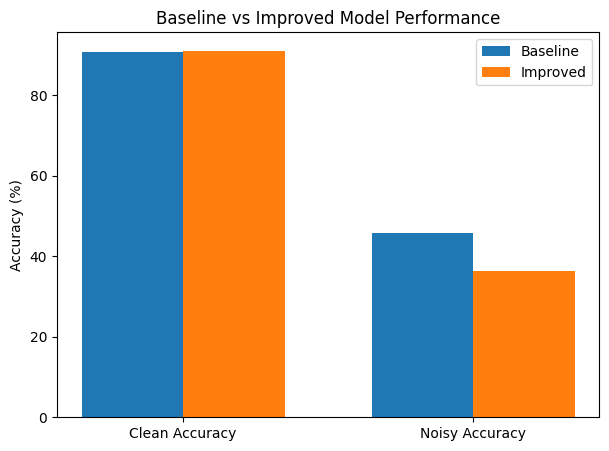

In [11]:
# VISUAL COMPARISON (OPTIONAL)

import numpy as np

labels = ['Clean Accuracy', 'Noisy Accuracy']
baseline_scores = [baseline_clean_acc, baseline_noisy_acc]
improved_scores = [improved_clean_acc, improved_noisy_acc]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, improved_scores, width, label='Improved')

plt.xticks(x, labels)
plt.title("Baseline vs Improved Model Performance")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()



=== Baseline Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.86      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.94      0.74      0.83      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.80      0.89      0.84      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.72      0.77      0.74      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


=== Improved Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.90      0.88      1000
     Trouser       0.99      0.98      0.99      100

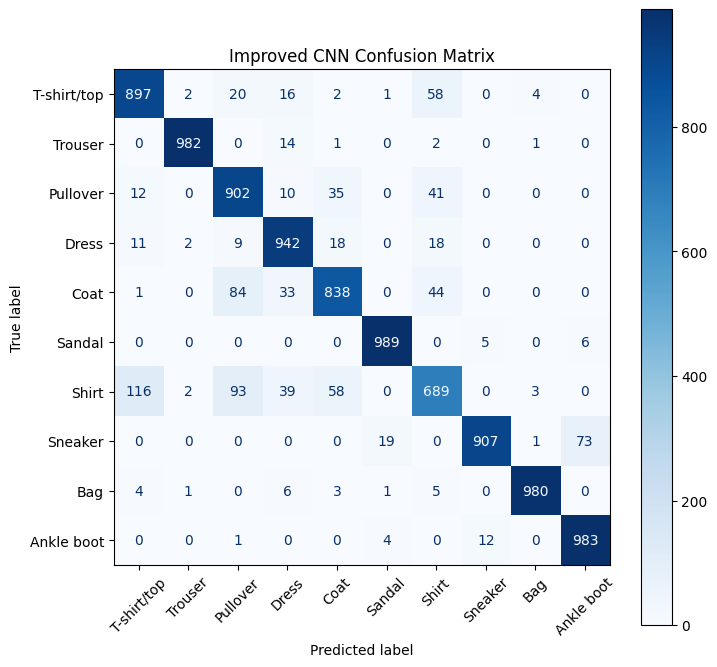

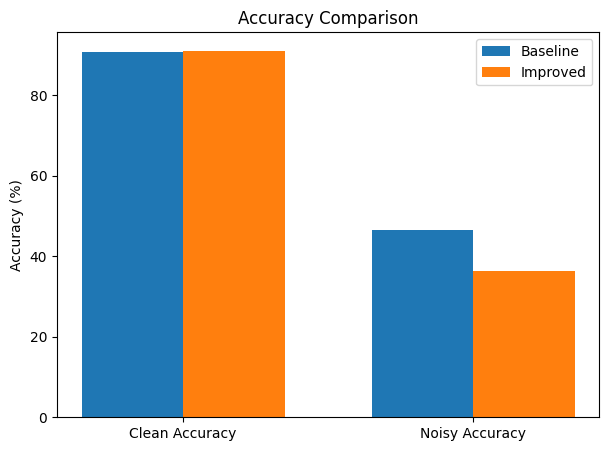

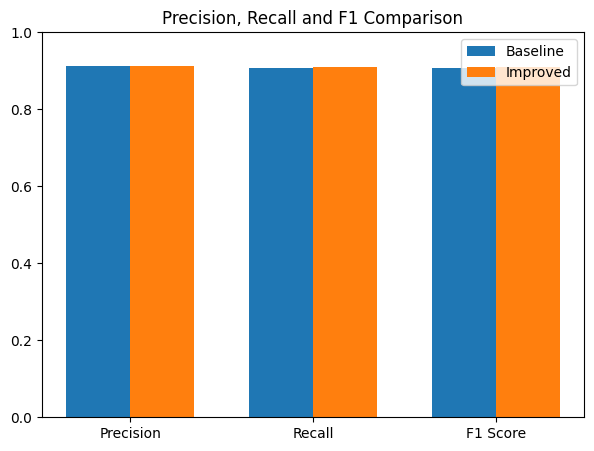

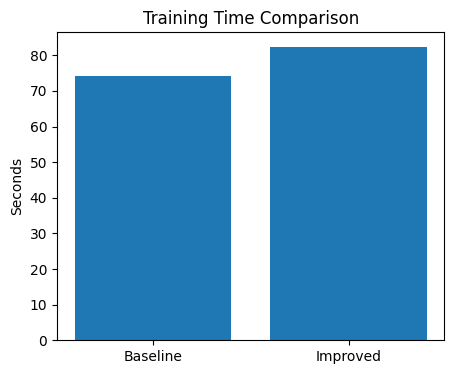

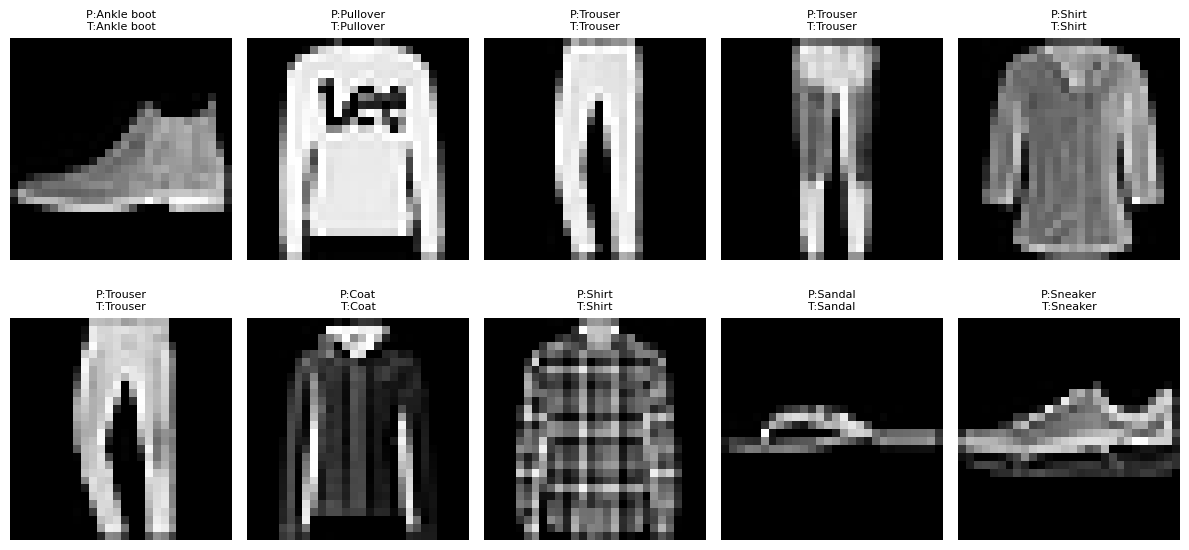

In [12]:
# ADDITIONAL EVALUATION AND VISUALISATIONS

class_names = train_dataset.classes

# Re-evaluate to collect metrics
baseline_clean_acc, baseline_precision, baseline_recall, baseline_f1, baseline_labels, baseline_preds = evaluate_model(baseline_model, test_loader)
baseline_noisy_acc, _, _, _, _, _ = evaluate_model(baseline_model, test_loader, noisy=True)

improved_clean_acc, improved_precision, improved_recall, improved_f1, improved_labels, improved_preds = evaluate_model(improved_model, test_loader)
improved_noisy_acc, _, _, _, _, _ = evaluate_model(improved_model, test_loader, noisy=True)

print("\n=== Baseline Classification Report ===")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))

print("\n=== Improved Classification Report ===")
print(classification_report(improved_labels, improved_preds, target_names=class_names))

# Confusion Matrix - Improved
cm = confusion_matrix(improved_labels, improved_preds)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Improved CNN Confusion Matrix")
plt.show()

# Accuracy comparison
labels = ["Clean Accuracy", "Noisy Accuracy"]
baseline = [baseline_clean_acc, baseline_noisy_acc]
improved = [improved_clean_acc, improved_noisy_acc]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7,5))
plt.bar(x-width/2, baseline, width, label="Baseline")
plt.bar(x+width/2, improved, width, label="Improved")
plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# Precision / Recall / F1
metrics = ["Precision","Recall","F1 Score"]
base_scores = [baseline_precision, baseline_recall, baseline_f1]
imp_scores = [improved_precision, improved_recall, improved_f1]

x = np.arange(len(metrics))
plt.figure(figsize=(7,5))
plt.bar(x-width/2, base_scores, width, label="Baseline")
plt.bar(x+width/2, imp_scores, width, label="Improved")
plt.xticks(x, metrics)
plt.ylim(0,1)
plt.title("Precision, Recall and F1 Comparison")
plt.legend()
plt.show()

# Training Time
plt.figure(figsize=(5,4))
plt.bar(["Baseline","Improved"], [baseline_time, improved_time])
plt.ylabel("Seconds")
plt.title("Training Time Comparison")
plt.show()

# Sample Predictions
images, labels = next(iter(test_loader))
images = images.to(device)
outputs = improved_model(images)
_, preds = torch.max(outputs,1)
images = images.cpu()

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()
